Churn Probability: 0.7443787955411965
Persona: High-Risk Price Sensitive
Urgency: high
Actions: ['Immediate outbound call', '20% bill discount for 3 months', 'Offer 12-month contract migration', 'Free security + backup add-ons']
Top Reasons: [{'feature': 'Contract', 'value': 'Month-to-month', 'impact': 0.467}, {'feature': 'Tenure', 'value': None, 'impact': 0.444}, {'feature': 'Internet Service', 'value': 'Fiber optic', 'impact': 0.274}]


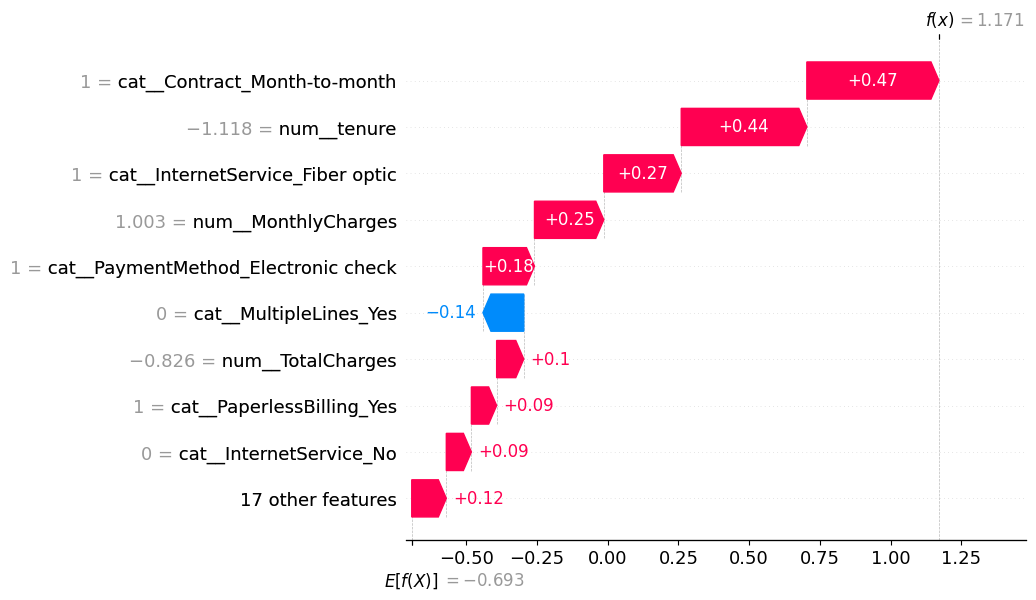

In [2]:
import joblib
import pandas as pd
import numpy as np
import shap
from typing import Dict, Any
import re

# Paths
MODEL_PATH = "../artifacts/churn_model_package.joblib"
SEGMENTATION_MODEL_PATH = "../artifacts/customer_segmentation_package.joblib"

# ==========================================================
# Load Artifacts
# ==========================================================

churn_pkg = joblib.load(MODEL_PATH)
seg_pkg = joblib.load(SEGMENTATION_MODEL_PATH)

churn_model = churn_pkg["model"]
THRESHOLDS = churn_pkg["thresholds"]

kproto = seg_pkg["model"]
scaler = seg_pkg["scaler"]
num_cols = seg_pkg["num_cols"]
cat_cols = seg_pkg["cat_cols"]
categorical_idx = seg_pkg["categorical_idx"]

# ==========================================================
# Extract Pipeline Components
# ==========================================================

pipe = churn_model.estimator.estimator
preprocessor = pipe.named_steps["preprocessor"]
xgb_model = pipe.named_steps["model"]

explainer = shap.TreeExplainer(xgb_model)

EXPECTED_FEATURES = list(preprocessor.feature_names_in_)

# ==========================================================
# Urgency Bucket
# ==========================================================

def churn_bucket(prob: float) -> str:
    if prob >= THRESHOLDS["conservative"]:
        return "high"
    elif prob >= THRESHOLDS["balanced"]:
        return "medium"
    elif prob >= THRESHOLDS["aggressive"]:
        return "low"
    else:
        return "very_low"

# ==========================================================
# Personas
# ==========================================================

CLUSTER_PERSONA = {
    0: "Premium Loyalist",
    1: "High-Risk Price Sensitive",
    2: "Stable Low-Usage",
    3: "Low Engagement Budget"
}

# ==========================================================
# Action Library (explicit very_low added)
# ==========================================================

ACTION_LIBRARY = {
    "High-Risk Price Sensitive": {
        "high": [
            "Immediate outbound call",
            "20% bill discount for 3 months",
            "Offer 12-month contract migration",
            "Free security + backup add-ons"
        ],
        "medium": [
            "Targeted email with pricing bundles",
            "Upgrade internet speed offer"
        ],
        "low": ["Monitor"],
        "very_low": ["No action"]
    },
    "Low Engagement Budget": {
        "high": [
            "Low-cost retention plan",
            "Free TechSupport trial",
            "Education email about services"
        ],
        "medium": ["Product education campaign"],
        "low": ["Monitor"],
        "very_low": ["No action"]
    },
    "Premium Loyalist": {
        "high": [
            "Dedicated account manager call",
            "Loyalty rewards",
            "Premium upgrade"
        ],
        "medium": ["VIP appreciation email"],
        "low": ["No action"],
        "very_low": ["No action"]
    },
    "Stable Low-Usage": {
        "high": [
            "Contract renewal incentive",
            "Cross-sell streaming bundle"
        ],
        "medium": ["Upsell bundle"],
        "low": ["No action"],
        "very_low": ["No action"]
    }
}

# ==========================================================
# Helper: Compute Persona
# ==========================================================

def compute_persona(df: pd.DataFrame):
    num_scaled = scaler.transform(df[num_cols])

    seg_input = pd.concat(
        [
            pd.DataFrame(num_scaled, columns=num_cols),
            df[cat_cols].reset_index(drop=True)
        ],
        axis=1
    )

    cluster = int(kproto.predict(seg_input.values, categorical=categorical_idx)[0])
    persona = CLUSTER_PERSONA.get(cluster, "Unknown")

    return cluster, persona

# ==========================================================
# Helper: Compute Churn
# ==========================================================

def compute_churn(df: pd.DataFrame):
    churn_prob = float(churn_model.predict_proba(df)[0, 1])
    urgency = churn_bucket(churn_prob)
    return churn_prob, urgency

# ==========================================================
# Helper: SHAP Base Value
# ==========================================================

def get_shap_base():
    base = explainer.expected_value
    return base[1] if isinstance(base, (list, np.ndarray)) else base

# ==========================================================
# Helper: Compute SHAP
# ==========================================================

def compute_shap_single(df: pd.DataFrame):

    X_trans = preprocessor.transform(df)
    feature_names = preprocessor.get_feature_names_out()

    X_trans_df = pd.DataFrame(
        X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans,
        columns=feature_names
    )

    shap_raw = explainer.shap_values(X_trans_df)

    if isinstance(shap_raw, list):
        shap_vals = shap_raw[1][0]
    else:
        shap_vals = shap_raw[0]

    return shap_vals, X_trans_df

# ==========================================================
# Helper: Top Reasons (JSON safe)
# ==========================================================

def parse_shap_feature_name(raw_name: str):

    name = raw_name.replace("cat__", "").replace("num__", "")

    if "_" in name:
        parts = name.split("_", 1)
        feature = re.sub(r"([a-z])([A-Z])", r"\1 \2", parts[0])
        feature = feature.replace("_", " ")
        value = parts[1]
        return feature.title(), value
    else:
        feature = re.sub(r"([a-z])([A-Z])", r"\1 \2", name)
        return feature.title(), None

def extract_top_reasons(shap_values, feature_names, top_n=3):
    abs_vals = np.abs(shap_values)
    idx = np.argsort(abs_vals)[::-1][:top_n]

    results = []

    for i in idx:
        feature_name = feature_names[i]
        feature, value = parse_shap_feature_name(feature_name)

        results.append({
            "feature": feature,
            "value": value,
            "impact": round(float(shap_values[i]), 3)
        })

    return results

# ==========================================================
# Prediction 
# ==========================================================

def predict_customer(customer_dict: Dict[str, Any]) -> Dict[str, Any]:

    df = pd.DataFrame([customer_dict])

    # Enforce schema
    df = df.reindex(columns=EXPECTED_FEATURES)

    # Persona
    cluster, persona = compute_persona(df)

    # Churn
    churn_prob, urgency = compute_churn(df)

    # SHAP
    shap_vals, X_trans_df = compute_shap_single(df)
    base = get_shap_base()

    reasons = extract_top_reasons(shap_vals, X_trans_df.columns.tolist())

    actions = ACTION_LIBRARY.get(persona, {}).get(urgency, ["Monitor"])

    return {
        "churn_probability": churn_prob,
        "urgency": urgency,
        "cluster": cluster,
        "persona": persona,
        "top_reasons": reasons,
        "recommended_actions": actions,
        "shap_values": shap_vals.tolist(),
        "shap_base": float(base),
        "shap_features": X_trans_df.columns.tolist(),
        "shap_data": X_trans_df.iloc[0].tolist()
    }

# ==========================================================
# Example Usage
# ==========================================================

if __name__ == "__main__":

    sample_customer = {
        "gender": "Male",
        "SeniorCitizen": "No",
        "Partner": "No",
        "Dependents": "No",
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "No",
        "StreamingMovies": "No",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "tenure": 5,
        "MonthlyCharges": 95.2,
        "TotalCharges": 410.3
    }

    result = predict_customer(sample_customer)

    print("Churn Probability:", result["churn_probability"])
    print("Persona:", result["persona"])
    print("Urgency:", result["urgency"])
    print("Actions:", result["recommended_actions"])
    print("Top Reasons:", result["top_reasons"])

    shap.waterfall_plot(
    shap.Explanation(
        values=np.array(result["shap_values"]),
        base_values=result["shap_base"],
        data=np.array(result["shap_data"]),
        feature_names=result["shap_features"]
        )
    )